In [1]:
#imported all the required libraries
import sys
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

sys.path.insert(0, '/Users/cezar/Documents/Documents_mac/University/TUe/Q6/gym-unbalanced-disk')
import gym_unbalanced_disk

## Environment


In [2]:
class SimToRealWrapper(gym.Wrapper):
    """
    Domain randomisation for sim-to-real transfer.

    - omega_noise_std : ω is estimated by differencing encoder ticks, not measured directly
    - th_noise_std    : small angle encoder noise
    - fc_range        : Coulomb friction varies with temperature and wear
    """
    def __init__(self, env, th_noise_std=0.01, omega_noise_std=0.05, fc_range=(8.0, 12.0)):
        super().__init__(env)
        self.th_noise_std    = th_noise_std
        self.omega_noise_std = omega_noise_std
        self.fc_range        = fc_range

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.env.unwrapped.Fc = float(np.random.uniform(*self.fc_range))
        return self._add_noise(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._add_noise(obs), reward, terminated, truncated, info

    def _add_noise(self, obs):
        obs = obs.copy().astype(np.float64)
        th_n  = np.random.normal(0, self.th_noise_std)
        obs[0] = obs[0] * np.cos(th_n) + obs[1] * np.sin(th_n)
        obs[1] = obs[1] * np.cos(th_n) - obs[0] * np.sin(th_n)
        obs[2] += np.random.normal(0, self.omega_noise_std)
        return obs.astype(np.float32)


def make_env(domain_rand=True):
    env = gym.make('unbalanced-disk-sincos-v0')
    env.unwrapped.Fc = 10.0

    def reward_fn(self):
        pos = 0.5 * (1.0 - np.cos(self.th))
        return pos * (1.0 - 0.01 * self.omega ** 2)

    env.unwrapped.reward_fun = reward_fn
    if domain_rand:
        env = SimToRealWrapper(env)
    return env


env = make_env()
print('obs space   :', env.observation_space)
print('action space:', env.action_space)
print('Fc (sample) :', env.unwrapped.Fc)

obs space   : Box([ -1.  -1. -40.], [ 1.  1. 40.], (3,), float32)
action space: Box(-3.0, 3.0, (), float32)
Fc (sample) : 10.0


## PPO Training


In [3]:
import os

MODEL_NAME = 'ppo_swingup_domrand'

if os.path.exists(f'{MODEL_NAME}.zip'):
    model = PPO.load(MODEL_NAME)
    print(f'Loaded {MODEL_NAME}.')
else:
    vec_env = make_vec_env(make_env, n_envs=4)
    model = PPO('MlpPolicy', vec_env, learning_rate=3e-4, gamma=0.99,
                ent_coef=0.01, n_steps=1024, batch_size=64, verbose=1, seed=42)
    model.learn(total_timesteps=500_000)
    model.save(MODEL_NAME)
    print(f'Training done, saved {MODEL_NAME}.')

Loaded ppo_swingup_domrand.


## Evaluation

/Users/cezar/.venvs/mechtire/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be float32, actual type: float64
  logger.warn(
/Users/cezar/.venvs/mechtire/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
/Users/cezar/.venvs/mechtire/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be float32, actual type: float64
  logger.warn(
/Users/cezar/.venvs/mechtire/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation s

Total reward: 277.9 / 300


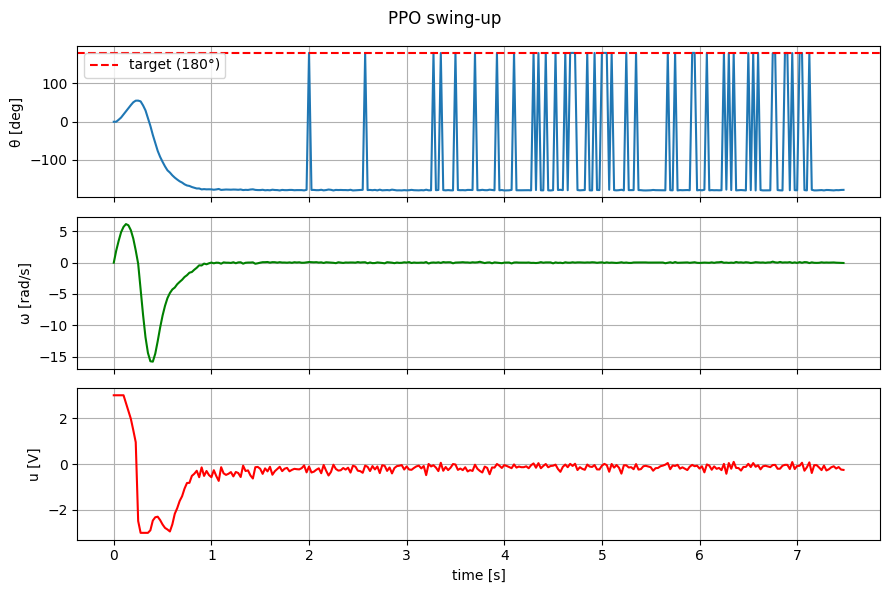

In [4]:
env = make_env()
obs, _ = env.reset()
obs_hist, act_hist, rew_hist = [], [], []

done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs_hist.append(obs.copy())
    act_hist.append(float(action))
    obs, r, terminated, truncated, _ = env.step(action)
    rew_hist.append(r)
    done = terminated or truncated

obs_arr = np.array(obs_hist)
th_deg  = np.degrees(np.arctan2(obs_arr[:, 0], obs_arr[:, 1]))
t       = np.arange(len(th_deg)) * 0.025

print(f'Total reward: {sum(rew_hist):.1f} / {len(rew_hist)}')

fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
axes[0].plot(t, th_deg)
axes[0].axhline(180, color='r', ls='--', label='target (180°)')
axes[0].set_ylabel('θ [deg]');  axes[0].legend();  axes[0].grid(True)
axes[1].plot(t, obs_arr[:, 2], 'g')
axes[1].set_ylabel('ω [rad/s]');  axes[1].grid(True)
axes[2].plot(t, act_hist, 'r')
axes[2].set_ylabel('u [V]');  axes[2].set_xlabel('time [s]');  axes[2].grid(True)
plt.suptitle('PPO swing-up')
plt.tight_layout()
plt.show()

## Robust PPO — Wider Domain Randomisation


In [5]:
def make_env_robust():
    env = gym.make('unbalanced-disk-sincos-v0')
    env.unwrapped.Fc = 10.0

    def reward_fn(self):
        pos = 0.5 * (1.0 - np.cos(self.th))
        return pos * (1.0 - 0.01 * self.omega ** 2)

    env.unwrapped.reward_fun = reward_fn
    env = SimToRealWrapper(env,
                           th_noise_std=0.02,
                           omega_noise_std=0.1,
                           fc_range=(6.0, 14.0))
    return env


ROBUST_NAME = 'ppo_swingup_robust'

if os.path.exists(f'{ROBUST_NAME}.zip'):
    model_robust = PPO.load(ROBUST_NAME)
    print(f'Loaded {ROBUST_NAME}.')
else:
    vec_env_robust = make_vec_env(make_env_robust, n_envs=4)
    model_robust = PPO('MlpPolicy', vec_env_robust,
                       learning_rate=3e-4,
                       gamma=0.99,
                       ent_coef=0.02,
                       n_steps=2048,
                       batch_size=64,
                       verbose=1,
                       seed=0)
    model_robust.learn(total_timesteps=300_000)
    model_robust.save(ROBUST_NAME)
    print(f'Training done, saved {ROBUST_NAME}.')

Loaded ppo_swingup_robust.


## Evaluation — Robust Model

Total reward: 272.7 / 300


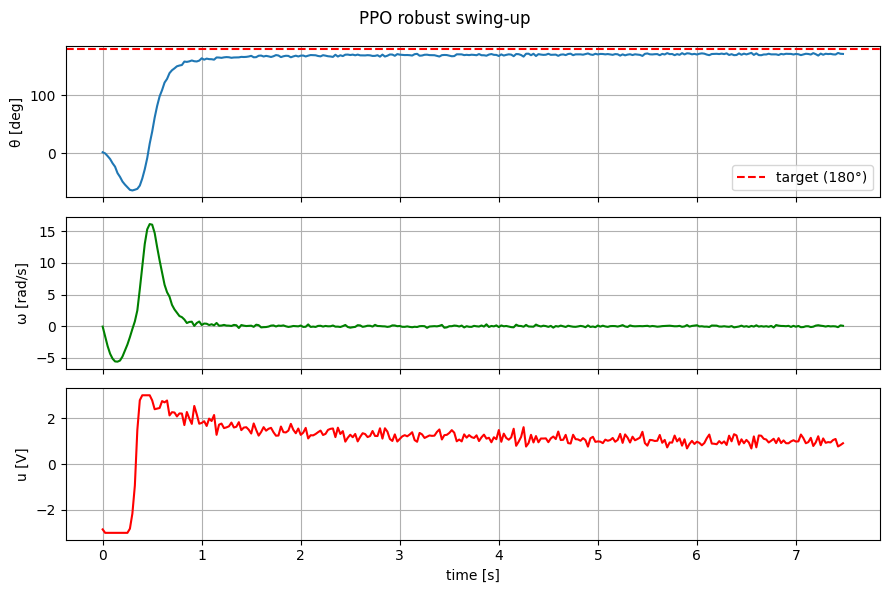

In [6]:
env_e = make_env_robust()
obs, _ = env_e.reset()
obs_hist, act_hist, rew_hist = [], [], []

done = False
while not done:
    action, _ = model_robust.predict(obs, deterministic=True)
    obs_hist.append(obs.copy())
    act_hist.append(float(action))
    obs, r, terminated, truncated, _ = env_e.step(action)
    rew_hist.append(r)
    done = terminated or truncated

obs_arr = np.array(obs_hist)
th_deg  = np.degrees(np.arctan2(obs_arr[:, 0], obs_arr[:, 1]))
t       = np.arange(len(th_deg)) * 0.025

print(f'Total reward: {sum(rew_hist):.1f} / {len(rew_hist)}')

fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
axes[0].plot(t, th_deg)
axes[0].axhline(180, color='r', ls='--', label='target (180°)')
axes[0].set_ylabel('θ [deg]');  axes[0].legend();  axes[0].grid(True)
axes[1].plot(t, obs_arr[:, 2], 'g')
axes[1].set_ylabel('ω [rad/s]');  axes[1].grid(True)
axes[2].plot(t, act_hist, 'r')
axes[2].set_ylabel('u [V]');  axes[2].set_xlabel('time [s]');  axes[2].grid(True)
plt.suptitle('PPO robust swing-up')
plt.tight_layout()
plt.show()

## Fine-Tuning: Hold at 180°

In [7]:
def make_env_finetune():
    env = gym.make('unbalanced-disk-sincos-v0')
    env.unwrapped.Fc = 10.0

    def reward_fn(self):
        # Angular error to top — handles wrapping correctly
        err = np.arctan2(np.sin(self.th - np.pi), np.cos(self.th - np.pi))
        pos = np.exp(-err ** 2 / (2 * (np.pi / 7) ** 2))
        return float(pos * (1.0 - 0.01 * self.omega ** 2))

    env.unwrapped.reward_fun = reward_fn
    env = SimToRealWrapper(env,
                           th_noise_std=0.01,
                           omega_noise_std=0.05,
                           fc_range=(8.0, 12.0))
    return env


# Quick check — reward at top vs reward at 90°
import gymnasium as gym 
env_test = make_env_finetune()
env_test.unwrapped.th = np.pi;         env_test.unwrapped.omega = 0
print(f'Reward at top (θ=180°, ω=0): {env_test.unwrapped.reward_fun(env_test.unwrapped):.3f}')
env_test.unwrapped.th = np.pi / 2
print(f'Reward at side (θ=90°,  ω=0): {env_test.unwrapped.reward_fun(env_test.unwrapped):.3f}')

Reward at top (θ=180°, ω=0): 1.000
Reward at side (θ=90°,  ω=0): 0.002


In [8]:
BASE_MODEL = 'ppo_swingup_robust'   # or 'ppo_swingup_robust'
FT_MODEL   = 'ppo_swingup_finetune'

if os.path.exists(f'{FT_MODEL}.zip'):
    model_ft = PPO.load(FT_MODEL)
    print(f'Loaded {FT_MODEL}.')
else:
    vec_env_ft = make_vec_env(make_env_finetune, n_envs=4)
    # Load base model and attach the new environment
    model_ft = PPO.load(BASE_MODEL, env=vec_env_ft)
    # Lower learning rate and entropy — we want refinement, not relearning
    model_ft.learning_rate = 1e-4
    model_ft.ent_coef      = 0.002
    model_ft.learn(total_timesteps=200_000, reset_num_timesteps=False)
    model_ft.save(FT_MODEL)
    print(f'Fine-tuning done, saved {FT_MODEL}.')

Loaded ppo_swingup_finetune.


## Evaluation — Fine-Tuned Model

Total reward: 274.7 / 300


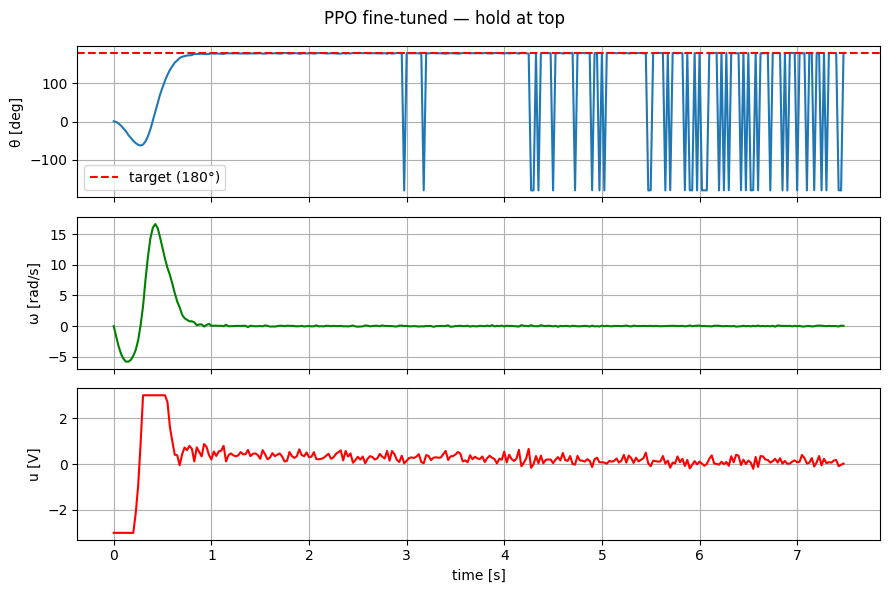

In [9]:
env_e = make_env_finetune()
obs, _ = env_e.reset()
obs_hist, act_hist, rew_hist = [], [], []

done = False
while not done:
    action, _ = model_ft.predict(obs, deterministic=True)
    obs_hist.append(obs.copy())
    act_hist.append(float(action))
    obs, r, terminated, truncated, _ = env_e.step(action)
    rew_hist.append(r)
    done = terminated or truncated

obs_arr = np.array(obs_hist)
th_deg  = np.degrees(np.arctan2(obs_arr[:, 0], obs_arr[:, 1]))
t       = np.arange(len(th_deg)) * 0.025

print(f'Total reward: {sum(rew_hist):.1f} / {len(rew_hist)}')

fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
axes[0].plot(t, th_deg)
axes[0].axhline(180, color='r', ls='--', label='target (180°)')
axes[0].set_ylabel('θ [deg]');  axes[0].legend();  axes[0].grid(True)
axes[1].plot(t, obs_arr[:, 2], 'g')
axes[1].set_ylabel('ω [rad/s]');  axes[1].grid(True)
axes[2].plot(t, act_hist, 'r')
axes[2].set_ylabel('u [V]');  axes[2].set_xlabel('time [s]');  axes[2].grid(True)
plt.suptitle('PPO fine-tuned — hold at top')
plt.tight_layout()
plt.show()

## Maximum-Reward Fine-Tune — Curriculum to 300

The current models score ~281/300, we try to fine tune it:
The swing-up skill is inherited from `ppo_swingup_robust` — fine-tuning uses a lower
learning rate (1 × 10⁻⁴) and entropy coefficient (0.005) to refine rather than relearn.



In [10]:

class SimToRealWrapper(gym.Wrapper):
    """Domain randomisation — duplicate here so this section runs standalone."""
    def __init__(self, env, th_noise_std=0.01, omega_noise_std=0.05, fc_range=(8.0, 12.0)):
        super().__init__(env)
        self.th_noise_std    = th_noise_std
        self.omega_noise_std = omega_noise_std
        self.fc_range        = fc_range

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.env.unwrapped.Fc = float(np.random.uniform(*self.fc_range))
        return self._add_noise(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._add_noise(obs), reward, terminated, truncated, info

    def _add_noise(self, obs):
        obs = obs.copy().astype(np.float64)
        th_n   = np.random.normal(0, self.th_noise_std)
        obs[0] = obs[0] * np.cos(th_n) + obs[1] * np.sin(th_n)
        obs[1] = obs[1] * np.cos(th_n) - obs[0] * np.sin(th_n)
        obs[2] += np.random.normal(0, self.omega_noise_std)
        return obs.astype(np.float32)


class TopStartWrapper(gym.Wrapper):
    """
    Curriculum wrapper: p_top fraction of resets start near the top.

    Sets th ~ N(pi, th_std) and omega ~ N(0, omega_std) directly on the
    unwrapped env, then reads the sincos observation through the base env's
    get_obs().  The other (1 - p_top) fraction resets from the bottom as normal.
    """
    def __init__(self, env, p_top=0.5, th_std=0.25, omega_std=1.5):
        super().__init__(env)
        self.p_top     = p_top
        self.th_std    = th_std
        self.omega_std = omega_std

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        if np.random.rand() < self.p_top:
            u       = self.env.unwrapped
            u.th    = np.pi + np.random.normal(0, self.th_std)
            u.omega = np.random.normal(0, self.omega_std)
            obs     = np.array(u.get_obs(), dtype=np.float32)
        return obs, info


def make_env_max(domain_rand=True):
    env = gym.make('unbalanced-disk-sincos-v0')
    env.unwrapped.Fc = 10.0

    def reward_fn(self):
        pos = 0.5 * (1.0 - np.cos(self.th))
        return pos * (1.0 - 0.01 * self.omega ** 2)

    env.unwrapped.reward_fun = reward_fn
    if domain_rand:
        env = SimToRealWrapper(env, th_noise_std=0.01, omega_noise_std=0.05, fc_range=(8.0, 12.0))
    env = TopStartWrapper(env, p_top=0.5)
    return env

In [11]:
import os
from stable_baselines3 import PPO

MAX_NAME = 'ppo_swingup_max'

if os.path.exists(f'{MAX_NAME}.zip'):
    model_max = PPO.load(MAX_NAME)
    print(f'Loaded {MAX_NAME}.')
else:
    vec_env_max = make_vec_env(make_env_max, n_envs=4)
    model_max   = PPO.load('ppo_swingup_robust', env=vec_env_max)
    model_max.learning_rate = 1e-4
    model_max.ent_coef      = 0.005
    model_max.learn(total_timesteps=200_000, reset_num_timesteps=False)
    model_max.save(MAX_NAME)
    print(f'Fine-tuning done, saved {MAX_NAME}.')

Loaded ppo_swingup_max.


## Evaluation — Maximum-Reward Model

**Bottom start** — standard evaluation from θ = 0°.  

**Top start** — disc placed at θ = 180° 

Bottom start (from θ = 0°)  →  reward = 277.2 / 300


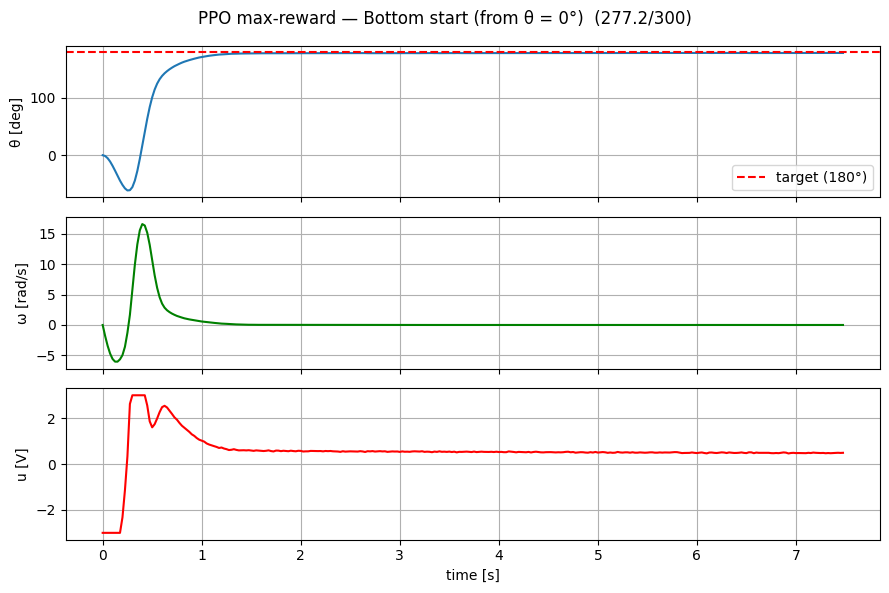

Top start   (pure hold)  →  reward = 300.0 / 300


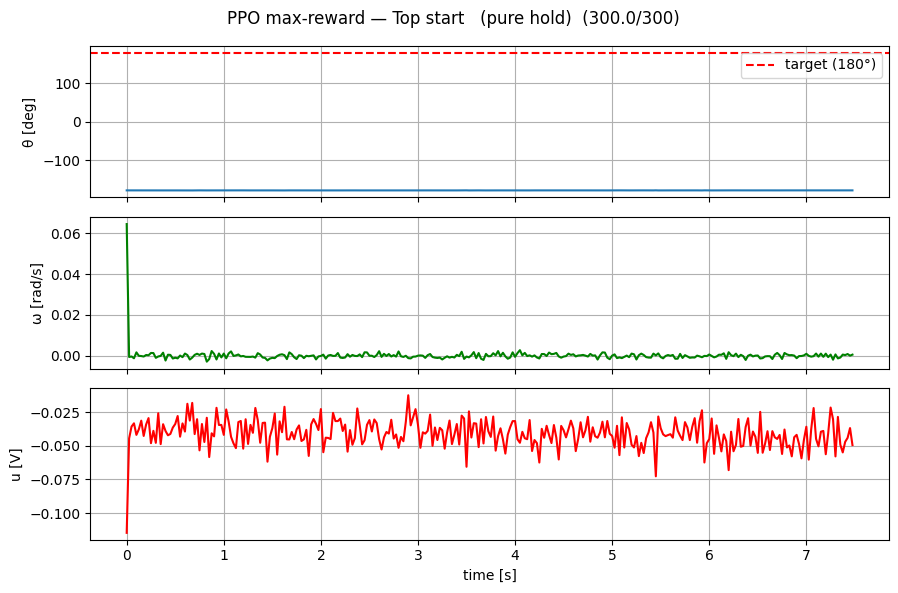

In [12]:
def _make_eval_env():
    """Clean evaluation env — no domain rand, no curriculum reset."""
    env = gym.make('unbalanced-disk-sincos-v0')
    env.unwrapped.Fc = 10.0

    def reward_fn(self):
        pos = 0.5 * (1.0 - np.cos(self.th))
        return pos * (1.0 - 0.01 * self.omega ** 2)

    env.unwrapped.reward_fun = reward_fn
    return env


def _eval_episode(model, start='bottom'):
    env_e = _make_eval_env()
    obs, _ = env_e.reset()
    if start == 'top':
        u       = env_e.unwrapped
        u.th    = np.pi + np.random.normal(0, np.radians(3))
        u.omega = np.random.normal(0, 0.2)
        obs     = np.array(u.get_obs(), dtype=np.float32)

    obs_hist, act_hist, rew_hist = [], [], []
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs_hist.append(obs.copy())
        act_hist.append(float(action))
        obs, r, terminated, truncated, _ = env_e.step(action)
        rew_hist.append(r)
        done = terminated or truncated
    return np.array(obs_hist), act_hist, rew_hist


for label, start in [('Bottom start (from \u03b8 = 0\u00b0)', 'bottom'),
                     ('Top start   (pure hold)',     'top')]:
    obs_arr, act_hist, rew_hist = _eval_episode(model_max, start=start)
    th_deg = np.degrees(np.arctan2(obs_arr[:, 0], obs_arr[:, 1]))
    t      = np.arange(len(th_deg)) * 0.025

    print(f'{label}  \u2192  reward = {sum(rew_hist):.1f} / {len(rew_hist)}')

    fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
    axes[0].plot(t, th_deg)
    axes[0].axhline(180, color='r', ls='--', label='target (180\u00b0)')
    axes[0].set_ylabel('\u03b8 [deg]');  axes[0].legend();  axes[0].grid(True)
    axes[1].plot(t, obs_arr[:, 2], 'g')
    axes[1].set_ylabel('\u03c9 [rad/s]');  axes[1].grid(True)
    axes[2].plot(t, act_hist, 'r')
    axes[2].set_ylabel('u [V]');  axes[2].set_xlabel('time [s]');  axes[2].grid(True)
    plt.suptitle(f'PPO max-reward \u2014 {label}  ({sum(rew_hist):.1f}/300)')
    plt.tight_layout()
    plt.show()
